In [1]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist, simulate_pulses_single_atom
from sim_library.sequences import gen_resonant_pm_seq, gen_offresonant_pm_seq, UpPulse, DownPulse, FreeEvolution, PulseSequence, gen_MDFE_seq
from sim_library.plotting import plot_state_trajectories, plot_bloch
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m
import matplotlib.pyplot as plt

### pi/4

#### phase - time scans

##### Even

In [ ]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*1e6
rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [8,9]
indices2 = [10,11]
indices3 = [12,13]
indices4 = [14,15]

indices_list = [indices, indices2, indices3, indices4]



pulse2_phases = np.linspace(-0.002*pi,0.002*pi,50)
avg_shifts = np.zeros(len(pulse2_phases))
stds_shifts = np.zeros(len(pulse2_phases))

for j, p2_phase in enumerate(pulse2_phases):
    shifts = np.linspace(0.7,0.8,100)
    phases = np.zeros((4, len(shifts)))

    for k, inds in enumerate(indices_list):
        initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
        initial_state[inds[0]] = 1
        initial_state[inds[1]] = 1
        initial_state = initial_state/ np.linalg.norm(initial_state)

        for i, shift in enumerate(shifts):
            duration = (pi/(4*dR))*shift

            mom_dependent_free_evolution = PulseSequence()

            down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
            down_pulse2 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, p2_phase), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
            freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


            mom_dependent_free_evolution.add_pulses([
                                                        down_pulse, freevolve, down_pulse2, freevolve,
                                                        ])


            wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

            phases[k, i] = ((np.angle(wave_func[-1,inds[1]]) - np.angle(wave_func[-1,inds[0]])) % (2*np.pi))/pi

            

    # print(phase)

    # print(rabi_time/duration)

    # plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

    cross = np.argmin(np.abs(np.array(phases[0,:]) - 0.25))
    cross2 = np.argmin(np.abs(np.array(phases[1,:]) - 1.25))
    cross3 = np.argmin(np.abs(np.array(phases[2,:]) - 0.25))
    cross4 = np.argmin(np.abs(np.array(phases[3,:]) - 1.25))
    shifts_arr = np.array([shifts[cross],shifts[cross2],shifts[cross3],shifts[cross4]])
    avg_shifts[j] = np.mean(shifts_arr)
    stds_shifts[j] = np.std(shifts_arr)




dingding = np.argmin(stds_shifts)

print(stds_shifts[dingding])
print(avg_shifts[dingding])
print(pulse2_phases[dingding]/pi)





0.0008023633404345168
0.7609109109109109
-0.0005050505050505053


In [ ]:
plt.plot(pulse2_phases/pi, avg_shifts)
plt.xlabel(r'Raman phase of MDFE pulses / $\pi$ (rad)')
plt.ylabel(r'Averaged free evolution time multiplier')
plt.title('Even momentum pairs')
plt.show()

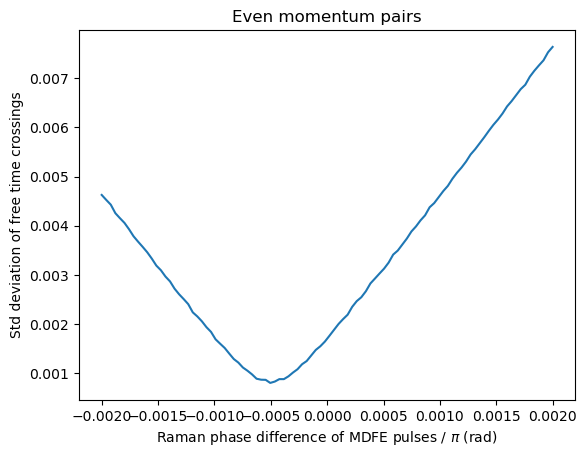

In [36]:
plt.plot(pulse2_phases/pi, stds_shifts)
plt.xlabel(r'Raman phase difference of MDFE pulses / $\pi$ (rad)')
plt.ylabel(r'Std deviation of free time crossings')
plt.title('Even momentum pairs')
plt.show()

##### Odd

In [51]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*1e6
rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [9,10]
indices2 = [11,12]
indices3 = [13,14]


indices_list = [indices, indices2, indices3]



pulse2_phases = np.linspace(0*pi,0.005*pi,125)
avg_shifts = np.zeros(len(pulse2_phases))
stds_shifts = np.zeros(len(pulse2_phases))

for j, p2_phase in enumerate(pulse2_phases):
    shifts = np.linspace(0.7,0.8,1000)
    phases = np.zeros((3, len(shifts)))

    for k, inds in enumerate(indices_list):
        initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
        initial_state[inds[0]] = 1
        initial_state[inds[1]] = 1
        initial_state = initial_state/ np.linalg.norm(initial_state)

        for i, shift in enumerate(shifts):
            duration = (pi/(4*dR))*shift

            mom_dependent_free_evolution = PulseSequence()

            up_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
            up_pulse2 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, p2_phase), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
            freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


            mom_dependent_free_evolution.add_pulses([
                                                        up_pulse, freevolve, up_pulse2, freevolve,
                                                        ])


            wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

            phases[k, i] = ((np.angle(wave_func[-1,inds[1]]) - np.angle(wave_func[-1,inds[0]])) % (2*np.pi))/pi

            

    # print(phase)

    # print(rabi_time/duration)

    # plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

    cross = np.argmin(np.abs(np.array(phases[0,:]) - 0.75))
    cross2 = np.argmin(np.abs(np.array(phases[1,:]) - 1.75))
    cross3 = np.argmin(np.abs(np.array(phases[2,:]) - 0.75))

    shifts_arr = np.array([shifts[cross],shifts[cross2],shifts[cross3],shifts[cross4]])
    avg_shifts[j] = np.mean(shifts_arr)
    stds_shifts[j] = np.std(shifts_arr)




dingding = np.argmin(stds_shifts)

print(stds_shifts[dingding])
print(avg_shifts[dingding])
print(pulse2_phases[dingding]/pi)





0.00040891227823743184
0.7600850850850851
0.0016129032258064518


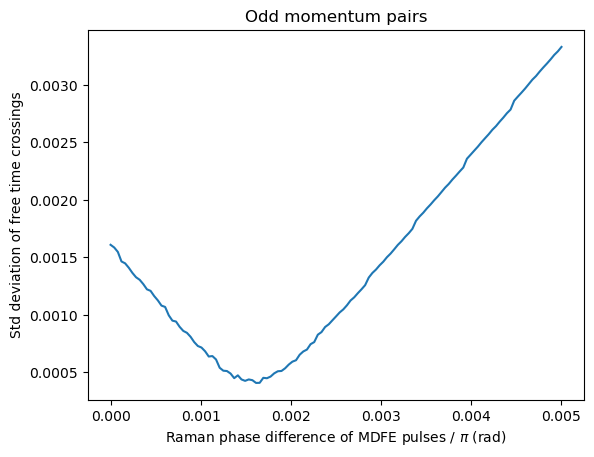

In [52]:
plt.plot(pulse2_phases/pi, stds_shifts)
plt.xlabel(r'Raman phase difference of MDFE pulses / $\pi$ (rad)')
plt.ylabel(r'Std deviation of free time crossings')
plt.title('Odd momentum pairs')
plt.show()

#### crossings

##### Even

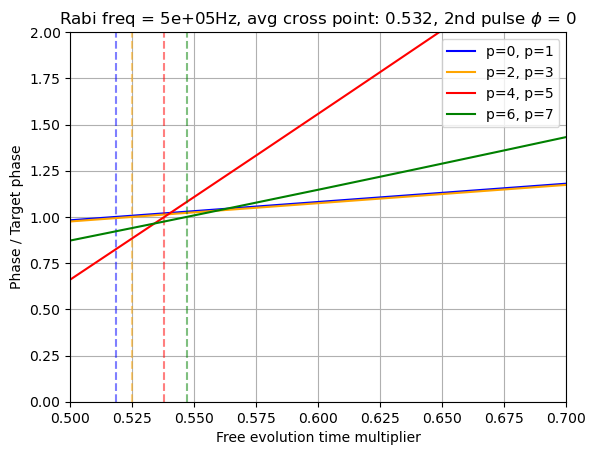

0.532032032032032


In [74]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [8,9]
indices2 = [10,11]
indices3 = [12,13]
indices4 = [14,15]

indices_list = [indices, indices2, indices3, indices4]


shifts = np.linspace(0.5,0.7,1000)
phases = np.zeros((4, len(shifts)))

for k, inds in enumerate(indices_list):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[inds[0]] = 1
    initial_state[inds[1]] = 1
    initial_state = initial_state/ np.linalg.norm(initial_state)

    for i, shift in enumerate(shifts):
        duration = (pi/(4*dR)) - ((1-shift)*pi/(4*dR))

        mom_dependent_free_evolution = PulseSequence()

        down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        down_pulse2 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0*pi), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


        mom_dependent_free_evolution.add_pulses([
                                                    down_pulse, freevolve, down_pulse2, freevolve,
                                                    ])


        wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

        phases[k, i] = ((np.angle(wave_func[-1,inds[1]]) - np.angle(wave_func[-1,inds[0]])) % (2*np.pi))/pi

            

# print(phase)

# print(rabi_time/duration)

# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

cross = np.argmin(np.abs(np.array(phases[0,:]) - 0.25))
cross2 = np.argmin(np.abs(np.array(phases[1,:]) - 1.25))
cross3 = np.argmin(np.abs(np.array(phases[2,:]) - 0.25))
cross4 = np.argmin(np.abs(np.array(phases[3,:]) - 1.25))
shifts_arr = np.array([shifts[cross],shifts[cross2],shifts[cross3],shifts[cross4]])
avg_shift = np.mean(shifts_arr)
stds_shift= np.std(shifts_arr)



x1 = [shifts[cross], shifts[cross]]
x2 = [shifts[cross2], shifts[cross2]]
x3 = [shifts[cross3], shifts[cross3]]
x4 = [shifts[cross4], shifts[cross4]]
y1 = [0, 2]


phases1 =  phases[0,:] / 0.25
phases2 = phases[1,:] / 1.25
phases3 = phases[2,:] / 0.25
phases4 = phases[3,:] / 1.25

plt.plot(shifts, phases1, c = 'blue', label = 'p=0, p=1')
plt.plot(x1,y1, c = 'blue', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases2, c = 'orange', label = 'p=2, p=3')
plt.plot(x2,y1, c = 'orange', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases3, c = 'red', label = 'p=4, p=5')
plt.plot(x3,y1, c = 'red', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases4, c = 'green', label = 'p=6, p=7')
plt.plot(x4,y1, c = 'green', linestyle = '--', alpha = 0.5)
plt.ylim(0,2)
plt.xlim(shifts[0], shifts[-1])

# plt.yticks([0, 0.5, 1, 1.5, 2], [r'0',r'$\pi/2$',r'$\pi$', r'$3\pi/2$', r'$2\pi$' ], fontsize = 12)
# plt.ylabel(r'Phase (rad)')

plt.ylabel(r'Phase / Target phase')
# plt.plot([0.7,1], [1,1], c = 'black', linestyle = '--', alpha = 0.5)
plt.grid()

plt.legend(loc = 'upper right')
plt.xlabel(r'Free evolution time multiplier')
plt.title(rf'Rabi freq = {rabi_freq/(2*pi):.0g}Hz, avg cross point: {avg_shift:.3f}, 2nd pulse $\phi$ = 0')
plt.show()

print(avg_shift)



##### Odd

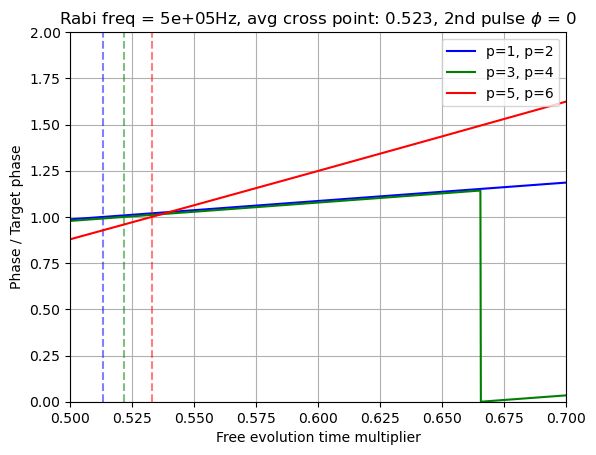

0.5226226226226226


In [75]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [9,10]
indices2 = [11,12]
indices3 = [13,14]


indices_list = [indices, indices2, indices3]


shifts = np.linspace(0.5,0.7,1000)
phases = np.zeros((3, len(shifts)))

for k, inds in enumerate(indices_list):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[inds[0]] = 1
    initial_state[inds[1]] = 1
    initial_state = initial_state/ np.linalg.norm(initial_state)

    for i, shift in enumerate(shifts):
        duration = (pi/(4*dR))*shift

        mom_dependent_free_evolution = PulseSequence()

        up_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        up_pulse2 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0*pi), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


        mom_dependent_free_evolution.add_pulses([
                                                    up_pulse, freevolve, up_pulse2, freevolve,
                                                    ])


        wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

        phases[k, i] = ((np.angle(wave_func[-1,inds[1]]) - np.angle(wave_func[-1,inds[0]])) % (2*np.pi))/pi

            

# print(phase)

# print(rabi_time/duration)

# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

cross = np.argmin(np.abs(np.array(phases[0,:]) - 0.75))
cross2 = np.argmin(np.abs(np.array(phases[1,:]) - 1.75))
cross3 = np.argmin(np.abs(np.array(phases[2,:]) - 0.75))

shifts_arr = np.array([shifts[cross],shifts[cross2],shifts[cross3]])
avg_shift = np.mean(shifts_arr)
stds_shift= np.std(shifts_arr)



x1 = [shifts[cross], shifts[cross]]
x2 = [shifts[cross2], shifts[cross2]]
x3 = [shifts[cross3], shifts[cross3]]

y1 = [0, 2]


phases1 =  phases[0,:] / 0.75
phases2 = phases[1,:] / 1.75
phases3 = phases[2,:] / 0.75


plt.plot(shifts, phases1, c = 'blue', label = 'p=1, p=2')
plt.plot(x1,y1, c = 'blue', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases2, c = 'green', label = 'p=3, p=4')
plt.plot(x2,y1, c = 'green', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases3, c = 'red', label = 'p=5, p=6')
plt.plot(x3,y1, c = 'red', linestyle = '--', alpha = 0.5)

plt.ylim(0,2)
plt.xlim(shifts[0], shifts[-1])

# plt.yticks([0, 0.5, 1, 1.5, 2], [r'0',r'$\pi/2$',r'$\pi$', r'$3\pi/2$', r'$2\pi$' ], fontsize = 12)
# plt.ylabel(r'Phase (rad)')

plt.ylabel(r'Phase / Target phase')
# plt.plot([0.7,1], [1,1], c = 'black', linestyle = '--', alpha = 0.5)
plt.grid()

plt.legend(loc = 'upper right')
plt.xlabel(r'Free evolution time multiplier')
plt.title(rf'Rabi freq = {rabi_freq/(2*pi):.0g}Hz, avg cross point: {avg_shift:.3f}, 2nd pulse $\phi$ = 0')
plt.show()

print(avg_shift)



### pi/8

#### crossings

##### even

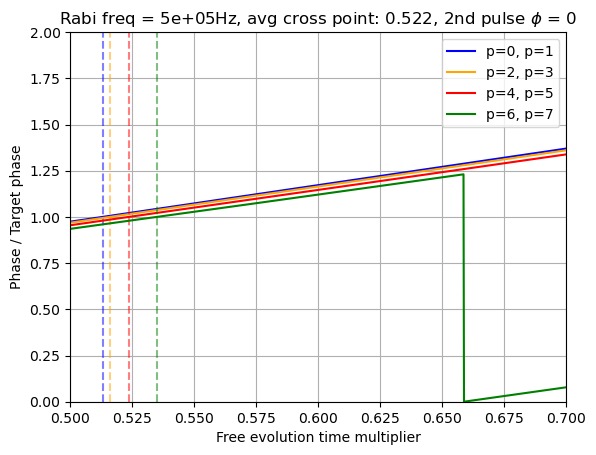

0.5219219219219219


In [76]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [8,9]
indices2 = [10,11]
indices3 = [12,13]
indices4 = [14,15]

indices_list = [indices, indices2, indices3, indices4]


shifts = np.linspace(0.5,0.7,1000)
phases = np.zeros((4, len(shifts)))

for k, inds in enumerate(indices_list):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[inds[0]] = 1
    initial_state[inds[1]] = 1
    initial_state = initial_state/ np.linalg.norm(initial_state)

    for i, shift in enumerate(shifts):
        duration = (pi/(8*dR)) - ((1-shift)*(pi/(4*dR)))

        mom_dependent_free_evolution = PulseSequence()

        down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        down_pulse2 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0*pi), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


        mom_dependent_free_evolution.add_pulses([
                                                    down_pulse, freevolve, down_pulse2, freevolve,
                                                    ])


        wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

        phases[k, i] = ((np.angle(wave_func[-1,inds[1]]) - np.angle(wave_func[-1,inds[0]])) % (2*np.pi))/pi

            

# print(phase)

# print(rabi_time/duration)

# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

cross = np.argmin(np.abs(np.array(phases[0,:]) - 0.125))
cross2 = np.argmin(np.abs(np.array(phases[1,:]) - 0.625))
cross3 = np.argmin(np.abs(np.array(phases[2,:]) - 1.125))
cross4 = np.argmin(np.abs(np.array(phases[3,:]) - 1.625))
shifts_arr = np.array([shifts[cross],shifts[cross2],shifts[cross3],shifts[cross4]])
avg_shift = np.mean(shifts_arr)
stds_shift= np.std(shifts_arr)



x1 = [shifts[cross], shifts[cross]]
x2 = [shifts[cross2], shifts[cross2]]
x3 = [shifts[cross3], shifts[cross3]]
x4 = [shifts[cross4], shifts[cross4]]
y1 = [0, 2]


phases1 =  phases[0,:] / 0.125
phases2 = phases[1,:] / 0.625
phases3 = phases[2,:] / 1.125
phases4 = phases[3,:] / 1.625

plt.plot(shifts, phases1, c = 'blue', label = 'p=0, p=1')
plt.plot(x1,y1, c = 'blue', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases2, c = 'orange', label = 'p=2, p=3')
plt.plot(x2,y1, c = 'orange', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases3, c = 'red', label = 'p=4, p=5')
plt.plot(x3,y1, c = 'red', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases4, c = 'green', label = 'p=6, p=7')
plt.plot(x4,y1, c = 'green', linestyle = '--', alpha = 0.5)
plt.ylim(0,2)
plt.xlim(shifts[0], shifts[-1])

# plt.yticks([0, 0.5, 1, 1.5, 2], [r'0',r'$\pi/2$',r'$\pi$', r'$3\pi/2$', r'$2\pi$' ], fontsize = 12)
# plt.ylabel(r'Phase (rad)')

plt.ylabel(r'Phase / Target phase')
# plt.plot([0.7,1], [1,1], c = 'black', linestyle = '--', alpha = 0.5)
plt.grid()

plt.legend(loc = 'upper right')
plt.xlabel(r'Free evolution time multiplier')
plt.title(rf'Rabi freq = {rabi_freq/(2*pi):.0g}Hz, avg cross point: {avg_shift:.3f}, 2nd pulse $\phi$ = 0')
plt.show()

print(avg_shift)



##### odd

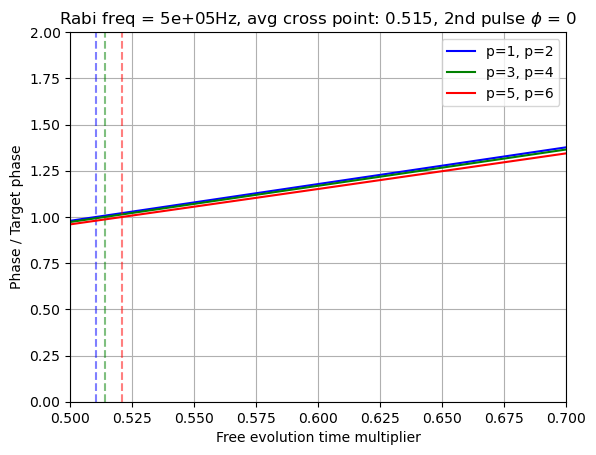

0.5151484818151485


In [77]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [9,10]
indices2 = [11,12]
indices3 = [13,14]


indices_list = [indices, indices2, indices3]


shifts = np.linspace(0.5,0.7,1000)
phases = np.zeros((3, len(shifts)))

for k, inds in enumerate(indices_list):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[inds[0]] = 1
    initial_state[inds[1]] = 1
    initial_state = initial_state/ np.linalg.norm(initial_state)

    for i, shift in enumerate(shifts):
        duration = (pi/(8*dR)) - ((1-shift)*(pi/(4*dR)))

        mom_dependent_free_evolution = PulseSequence()

        up_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        up_pulse2 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0*pi), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
        freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


        mom_dependent_free_evolution.add_pulses([
                                                    freevolve, up_pulse, freevolve, up_pulse2,
                                                    ])


        wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

        phases[k, i] = ((np.angle(wave_func[-1,inds[1]]) - np.angle(wave_func[-1,inds[0]])) % (2*np.pi))/pi

            

# print(phase)

# print(rabi_time/duration)

# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

cross = np.argmin(np.abs(np.array(phases[0,:]) - 0.375))
cross2 = np.argmin(np.abs(np.array(phases[1,:]) - 0.875))
cross3 = np.argmin(np.abs(np.array(phases[2,:]) - 1.375))

shifts_arr = np.array([shifts[cross],shifts[cross2],shifts[cross3]])
avg_shift = np.mean(shifts_arr)
stds_shift= np.std(shifts_arr)



x1 = [shifts[cross], shifts[cross]]
x2 = [shifts[cross2], shifts[cross2]]
x3 = [shifts[cross3], shifts[cross3]]

y1 = [0, 2]


phases1 =  phases[0,:] / 0.375
phases2 = phases[1,:] / 0.875
phases3 = phases[2,:] / 1.375


plt.plot(shifts, phases1, c = 'blue', label = 'p=1, p=2')
plt.plot(x1,y1, c = 'blue', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases2, c = 'green', label = 'p=3, p=4')
plt.plot(x2,y1, c = 'green', linestyle = '--', alpha = 0.5)
plt.plot(shifts, phases3, c = 'red', label = 'p=5, p=6')
plt.plot(x3,y1, c = 'red', linestyle = '--', alpha = 0.5)

plt.ylim(0,2)
plt.xlim(shifts[0], shifts[-1])

# plt.yticks([0, 0.5, 1, 1.5, 2], [r'0',r'$\pi/2$',r'$\pi$', r'$3\pi/2$', r'$2\pi$' ], fontsize = 12)
# plt.ylabel(r'Phase (rad)')

plt.ylabel(r'Phase / Target phase')
# plt.plot([0.7,1], [1,1], c = 'black', linestyle = '--', alpha = 0.5)
plt.grid()

plt.legend(loc = 'upper right')
plt.xlabel(r'Free evolution time multiplier')
plt.title(rf'Rabi freq = {rabi_freq/(2*pi):.0g}Hz, avg cross point: {avg_shift:.3f}, 2nd pulse $\phi$ = 0')
plt.show()

print(avg_shift)



#### std - phase scan

In [4]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*1e6
rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [8,9]
indices2 = [10,11]
indices3 = [12,13]
indices4 = [14,15]

indices_list = [indices, indices2, indices3, indices4]



pulse2_phases = np.linspace(-0.002*pi,0.002*pi,200)
avg_shifts = np.zeros(len(pulse2_phases))
stds_shifts = np.zeros(len(pulse2_phases))

for j, p2_phase in enumerate(pulse2_phases):
    shifts = np.linspace(0.4,0.6,200)
    phases = np.zeros((4, len(shifts)))

    for k, inds in enumerate(indices_list):
        initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
        initial_state[inds[0]] = 1
        initial_state[inds[1]] = 1
        initial_state = initial_state/ np.linalg.norm(initial_state)

        for i, shift in enumerate(shifts):
            duration = (pi/(8*dR))*shift

            mom_dependent_free_evolution = PulseSequence()

            down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
            down_pulse2 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, p2_phase), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
            freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


            mom_dependent_free_evolution.add_pulses([
                                                        down_pulse, freevolve, down_pulse2, freevolve,
                                                        ])


            wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

            phases[k, i] = ((np.angle(wave_func[-1,inds[1]]) - np.angle(wave_func[-1,inds[0]])) % (2*np.pi))/pi

            

    # print(phase)

    # print(rabi_time/duration)

    # plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

    cross = np.argmin(np.abs(np.array(phases[0,:]) - 0.125))
    cross2 = np.argmin(np.abs(np.array(phases[1,:]) - 0.625))
    cross3 = np.argmin(np.abs(np.array(phases[2,:]) - 1.125))
    cross4 = np.argmin(np.abs(np.array(phases[3,:]) - 1.625))
    shifts_arr = np.array([shifts[cross],shifts[cross2],shifts[cross3],shifts[cross4]])
    avg_shifts[j] = np.mean(shifts_arr)
    stds_shifts[j] = np.std(shifts_arr)




dingding = np.argmin(stds_shifts)

print(stds_shifts[dingding])
print(avg_shifts[dingding])
print(pulse2_phases[dingding]/pi)





0.0035086030260726197
0.521356783919598
-0.0007738693467336683


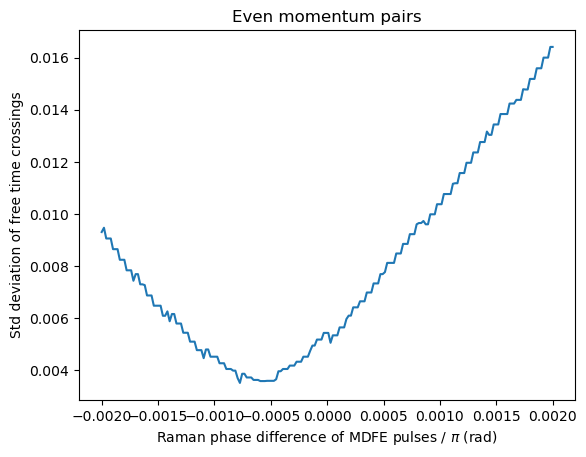

In [5]:
plt.plot(pulse2_phases/pi, stds_shifts)
plt.xlabel(r'Raman phase difference of MDFE pulses / $\pi$ (rad)')
plt.ylabel(r'Std deviation of free time crossings')
plt.title('Even momentum pairs')
plt.show()

##### odd

In [48]:
p_min = -8
p_max = 16
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*1e6
rabi_time = 2*pi/rabi_freq

time_steps = 1

indices = [9,10]
indices2 = [11,12]
indices3 = [13,14]


indices_list = [indices, indices2, indices3]



pulse2_phases = np.linspace(0.00*pi,0.005*pi,100)
avg_shifts = np.zeros(len(pulse2_phases))
stds_shifts = np.zeros(len(pulse2_phases))

for j, p2_phase in enumerate(pulse2_phases):
    shifts = np.linspace(0.4,0.6,500)
    phases = np.zeros((3, len(shifts)))

    for k, inds in enumerate(indices_list):
        initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
        initial_state[inds[0]] = 1
        initial_state[inds[1]] = 1
        initial_state = initial_state/ np.linalg.norm(initial_state)

        for i, shift in enumerate(shifts):
            duration = (pi/(8*dR))*shift

            mom_dependent_free_evolution = PulseSequence()

            up_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
            up_pulse2 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, p2_phase), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
            freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=duration/4)


            mom_dependent_free_evolution.add_pulses([
                                                        up_pulse, freevolve, up_pulse2, freevolve,
                                                        ])


            wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

            phases[k, i] = ((np.angle(wave_func[-1,inds[1]]) - np.angle(wave_func[-1,inds[0]])) % (2*np.pi))/pi

            

    # print(phase)

    # print(rabi_time/duration)

    # plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1]*-1)

    cross = np.argmin(np.abs(np.array(phases[0,:]) - 0.375))
    cross2 = np.argmin(np.abs(np.array(phases[1,:]) - 0.875))
    cross3 = np.argmin(np.abs(np.array(phases[2,:]) - 1.375))

    shifts_arr = np.array([shifts[cross],shifts[cross2],shifts[cross3]])
    avg_shifts[j] = np.mean(shifts_arr)
    stds_shifts[j] = np.std(shifts_arr)




dingding = np.argmin(stds_shifts)

print(stds_shifts[dingding])
print(avg_shifts[dingding])
print(pulse2_phases[dingding]/pi)





0.0013225778138425512
0.518370073480294
0.0015656565656565658


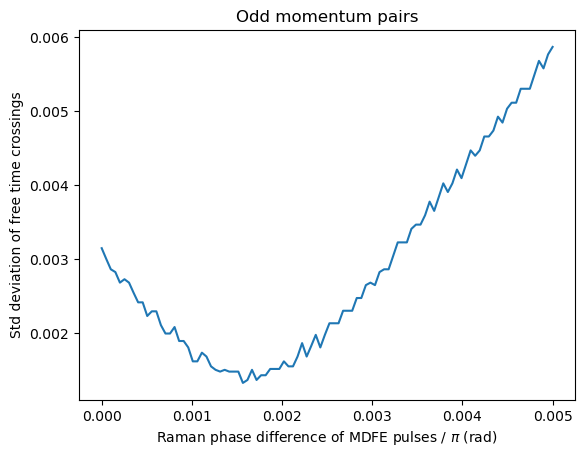

In [49]:
plt.plot(pulse2_phases/pi, stds_shifts)
plt.xlabel(r'Raman phase difference of MDFE pulses / $\pi$ (rad)')
plt.ylabel(r'Std deviation of free time crossings')
plt.title('Odd momentum pairs')
plt.show()

In [28]:
print(stds_shifts)

[0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874
 0.02875874 0.02875874 0.02875874 0.02875874 0.02875874 0.0287